## Dự đoán biển quảng cáo phù hợp với nhân khẩu học con người
- Dự án phân loại biển quảng cáo dựa trên các đặc trưng:thời điểm trong ngày, giới tính, độ tuôi.
- Biến đặc trưng Y là loại quảng cáo phù hợp. 
- Vì vậy việc mô hình hóa thuộc về bài toán phân loại

### 1. Xử lý dữ liệu thô trên 3 file trong folder raw_data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_raw_SAS = pd.read_csv('./data/raw_data/SAS_Dataset.csv')
df_raw_SAS.head()


,user_id,age,gender,location,language,browsing_history,purchase_history,frequently_visited_platforms,interests,ad_interactions_fashion,...,platform,device,campaign_goal,target_audience,brand_name,product_name,product_features,price_range,trends,competitor_names
0,U0001,49,Female,"Sydney, Australia",English,diet tips|tech news|fashion blogs,protein powder|lipstick,Instagram|YouTube|Reddit,Gaming|Technology,6,...,YouTube,Desktop,Direct Sales,Women aged 39-40 focused on Health,EcoStyle,Gaming Pro Headset,Organic cotton|Recyclable materials|Noise-canc...,$20-$100,#EcoChic|#GamingGear,HealthyYou|SustainStyle
1,U0002,42,Female,"New York, USA",English,fitness blogs|fashion blogs|beauty reviews,lipstick|running shoes,TikTok|Twitter|Pinterest,Health|Beauty,20,...,Pinterest,Mobile,Engagement,Men aged 37-40 focused on Fitness,FitLife,Gaming Pro Headset,Recyclable materials|Organic cotton|Noise-canc...,$30-$150,#SustainableStyle|#GamingGear,HealthyYou|GreenWear
2,U0003,31,Male,"Toronto, Canada",German,fitness blogs|beauty reviews|tech news,running shoes|protein powder,Reddit|Twitter|Instagram,Beauty|Gaming,4,...,TikTok,Desktop,Brand Awareness,Men aged 37-40 focused on Fitness,FitLife,Daily Wellness Pack,Organic cotton|Vegan ingredients|Recyclable ma...,$30-$150,#GamingGear|#EcoChic,NextTech|GreenWear
3,U0004,57,Female,"New York, USA",English,tech news|fashion blogs|fitness blogs,yoga mat|protein powder,YouTube|Pinterest|Snapchat,Technology|Gaming,6,...,Pinterest,Desktop,Direct Sales,Men aged 36-40 focused on Fitness,TechGizmo,Daily Wellness Pack,Recyclable materials|Organic cotton|Noise-canc...,$20-$100,#GamingGear|#EcoChic,GreenWear|NextTech
4,U0005,19,Male,"New York, USA",Spanish,diet tips|beauty reviews|fashion blogs,protein powder|yoga mat,TikTok|YouTube|Snapchat,Fitness|Technology,1,...,Instagram,Desktop,Lead Generation,Men aged 32-40 focused on Technology,TechGizmo,Gaming Pro Headset,Recyclable materials|Organic cotton|Vegan ingr...,$20-$100,#SustainableStyle|#GamingGear,NextTech|GreenWear


In [5]:
selected_columns = ['age','gender','location','ad_interactions_fashion','ad_interactions_tech', 'ad_interactions_fitness']
df_SAS = df_raw_SAS[selected_columns]
df_SAS.head()

,age,gender,location,ad_interactions_fashion,ad_interactions_tech,ad_interactions_fitness
0,49,Female,"Sydney, Australia",6,17,1
1,42,Female,"New York, USA",20,2,18
2,31,Male,"Toronto, Canada",4,8,19
3,57,Female,"New York, USA",6,2,8
4,19,Male,"New York, USA",1,4,17


In [12]:
df_SAS.count()

age                        1000
gender                     1000
location                   1000
ad_interactions_fashion    1000
ad_interactions_tech       1000
ad_interactions_fitness    1000
dtype: int64

In [13]:
#Lọc ra Loại quảng cáo có tương tác cao nhất
ad_columns = ['ad_interactions_fashion', 'ad_interactions_tech', 'ad_interactions_fitness']
df_SAS['max_ad_type'] = df_SAS[ad_columns].idxmax(axis=1).str.replace('ad_interactions_', '')
#Lọc ra quốc gia từ cột location
df_SAS['country'] = df_SAS['location'].str.split(',').str[-1].str.strip()
df_SAS.head()

,age,gender,location,ad_interactions_fashion,ad_interactions_tech,ad_interactions_fitness,max_ad_type,country
0,49,Female,"Sydney, Australia",6,17,1,tech,Australia
1,42,Female,"New York, USA",20,2,18,fashion,USA
2,31,Male,"Toronto, Canada",4,8,19,fitness,Canada
3,57,Female,"New York, USA",6,2,8,fitness,USA
4,19,Male,"New York, USA",1,4,17,fitness,USA


In [ ]:
df_SAS_new = df_SAS[['age','gender','country','max_ad_type']].copy()
df_SAS_new.head()


,age,gender,country,max_ad_type
0,49,Female,Australia,tech
1,42,Female,USA,fashion
2,31,Male,Canada,fitness
3,57,Female,USA,fitness
4,19,Male,USA,fitness


In [17]:
# Đếm số lượng từng loại quảng cáo
ad_counts = df_SAS_new['max_ad_type'].value_counts()
country_counts = df_SAS_new['country'].value_counts()
# Hiển thị kết quả
print("Số lượng bản ghi theo từng loại quảng cáo:")
print(ad_counts)
print("\nSố lượng bản ghi theo từng quốc gia:")
print(country_counts)

Số lượng bản ghi theo từng loại quảng cáo:
max_ad_type
fashion    349
fitness    326
tech       325
Name: count, dtype: int64

Số lượng bản ghi theo từng quốc gia:
country
USA          418
UK           204
Australia    195
Canada       183
Name: count, dtype: int64


In [7]:
df_raw_SMedia = pd.read_csv('./data/raw_data/SocialMedia_Dataset.csv')
selected_columns = ['age','gender','location','interests','impressions']
df_SMedia = df_raw_SMedia[selected_columns]
df_SMedia.head()

,age,gender,location,interests,impressions
0,58,M,USA,Food,3
1,55,F,USA,Tech,9
2,52,F,UK,Gaming,13
3,31,F,USA,Tech,14
4,52,M,India,Tech,10


In [9]:
trung_binh_impressions = df_SMedia['impressions'].mean()
trung_binh_impressions

np.float64(8.282)

In [19]:
df_loc = df_SMedia[df_SMedia['impressions'] >= 5]
print(df_loc.count())


age            375
gender         375
location       375
interests      375
impressions    375
dtype: int64


In [ ]:
interests_counts = df_loc['interests'].value_counts()
print(interests_counts)
country_counts_SMedia = df_loc['location'].value_counts()
print(country_counts_SMedia)
df_loc.head()
df_loc['country'] = df_loc['location']

interests
Tech       75
Food       62
Fitness    62
Travel     61
Gaming     59
Fashion    56
Name: count, dtype: int64
location
Australia    77
Germany      72
India        71
UK           58
Canada       53
USA          44
Name: count, dtype: int64


,age,gender,location,interests,impressions
1,55,F,USA,Tech,9
2,52,F,UK,Gaming,13
3,31,F,USA,Tech,14
4,52,M,India,Tech,10
5,32,F,USA,Fashion,8


In [56]:
df_data_form = pd.read_excel('./data/raw_data/data_form.xlsx')
df_data_form.head()

,Dấu thời gian,gender,age,time,ad_type_interests
0,2026-04-02 15:11:31.473,Nữ,18 - 25 tuổi,"Sáng (Khoảng 6h - 11h), Chiều (Khoảng 14h - 18...","Thời trang/Phụ kiện, Đồ ăn/Ẩm thực/Thực phẩm, ..."
1,2026-04-02 15:26:29.895,Nam,18 - 25 tuổi,"Chiều (Khoảng 14h - 18h), Tối (Khoảng 18h - 22h)","Công nghệ/Thiết bị điện tử, Giải trí/Phim ảnh/..."
2,2026-04-02 15:28:15.336,Nam,18 - 25 tuổi,"Sáng (Khoảng 6h - 11h), Chiều (Khoảng 14h - 18h)","Công nghệ/Thiết bị điện tử, Đồ ăn/Ẩm thực/Thực..."
3,2026-04-02 15:28:54.679,Nữ,18 - 25 tuổi,"Sáng (Khoảng 6h - 11h), Tối (Khoảng 18h - 22h)","Thời trang/Phụ kiện, Đồ ăn/Ẩm thực/Thực phẩm, ..."
4,2026-04-02 15:29:08.650,Nữ,18 - 25 tuổi,"Sáng (Khoảng 6h - 11h), Chiều (Khoảng 14h - 18...","Mỹ phẩm/Chăm sóc sắc đẹp, Du lịch/Trải nghiệm,..."


In [57]:
df_data_form['ad_type_interests'] = df_data_form['ad_type_interests'].str.split(',')
df_data_form = df_data_form.explode('ad_type_interests')
df_data_form['ad_type_interests'] = df_data_form['ad_type_interests'].str.strip()
mapping_ad = {
    'Công nghệ/Thiết bị điện tử': 'Tech',
    'Thời trang/Phụ kiện': 'Fashion',
    'Đồ ăn/Ẩm thực/Thực phẩm': 'Food',
    'Mỹ phẩm/Chăm sóc sắc đẹp': 'Health_and_Beauty',
    'Du lịch/Trải nghiệm': 'Travel',
    'Giải trí/Phim ảnh/Âm nhạc': 'Entertainment',
}

df_data_form['ad_type_interests'] = df_data_form['ad_type_interests'].map(mapping_ad)
print(df_data_form['ad_type_interests'].value_counts())


ad_type_interests
Food                 62
Tech                 57
Entertainment        56
Fashion              42
Health_and_Beauty    41
Travel               37
Name: count, dtype: int64


In [58]:
df_data_form.head(10)

,Dấu thời gian,gender,age,time,ad_type_interests
0,2026-04-02 15:11:31.473,Nữ,18 - 25 tuổi,"Sáng (Khoảng 6h - 11h), Chiều (Khoảng 14h - 18...",Fashion
0,2026-04-02 15:11:31.473,Nữ,18 - 25 tuổi,"Sáng (Khoảng 6h - 11h), Chiều (Khoảng 14h - 18...",Food
0,2026-04-02 15:11:31.473,Nữ,18 - 25 tuổi,"Sáng (Khoảng 6h - 11h), Chiều (Khoảng 14h - 18...",Health_and_Beauty
1,2026-04-02 15:26:29.895,Nam,18 - 25 tuổi,"Chiều (Khoảng 14h - 18h), Tối (Khoảng 18h - 22h)",Tech
1,2026-04-02 15:26:29.895,Nam,18 - 25 tuổi,"Chiều (Khoảng 14h - 18h), Tối (Khoảng 18h - 22h)",Entertainment
2,2026-04-02 15:28:15.336,Nam,18 - 25 tuổi,"Sáng (Khoảng 6h - 11h), Chiều (Khoảng 14h - 18h)",Tech
2,2026-04-02 15:28:15.336,Nam,18 - 25 tuổi,"Sáng (Khoảng 6h - 11h), Chiều (Khoảng 14h - 18h)",Food
2,2026-04-02 15:28:15.336,Nam,18 - 25 tuổi,"Sáng (Khoảng 6h - 11h), Chiều (Khoảng 14h - 18h)",Entertainment
3,2026-04-02 15:28:54.679,Nữ,18 - 25 tuổi,"Sáng (Khoảng 6h - 11h), Tối (Khoảng 18h - 22h)",Fashion
3,2026-04-02 15:28:54.679,Nữ,18 - 25 tuổi,"Sáng (Khoảng 6h - 11h), Tối (Khoảng 18h - 22h)",Food


### 2.Làm sạch và chuẩn hóa dữ liệu

In [23]:
df_SAS_new.head()


,age,gender,country,max_ad_type
0,49,Female,Australia,tech
1,42,Female,USA,fashion
2,31,Male,Canada,fitness
3,57,Female,USA,fitness
4,19,Male,USA,fitness


In [24]:
df_SMedia.head()

,age,gender,location,interests,impressions
0,58,M,USA,Food,3
1,55,F,USA,Tech,9
2,52,F,UK,Gaming,13
3,31,F,USA,Tech,14
4,52,M,India,Tech,10


In [29]:
df1 = df_SAS_new.rename(columns={'max_ad_type': 'ad_type_interests'})

df2 = df_SMedia[df_SMedia['impressions'] >= 5].rename(columns={'location': 'country', 'interests': 'ad_type_interests'}).drop(columns=['impressions'])
df_cleaned = pd.concat([df1, df2], ignore_index=True)
df_cleaned['gender'] = df_cleaned['gender'].replace({'F': 'Female', 'M': 'Male'})
df_cleaned.head(10)

,age,gender,country,ad_type_interests
0,49,Female,Australia,tech
1,42,Female,USA,fashion
2,31,Male,Canada,fitness
3,57,Female,USA,fitness
4,19,Male,USA,fitness
5,35,Male,Canada,fashion
6,34,Female,Australia,fashion
7,31,Male,Canada,tech
8,39,Male,Australia,fitness
9,29,Female,USA,fashion


In [30]:
df_cleaned.to_csv('./data/cleaned_data/cleaned_dataset.csv', index=False)

In [ ]:
df_data_form_new = df_data_form.copy()
df_data_form_new = df_data_form.drop(columns=['Dấu thời gian', 'time'])
df_data_form_new['gender'] = df_data_form_new['gender'].replace({'Nam': 'Male', 'Nữ': 'Female'})
df_data_form_new.head(10)

,gender,age,ad_type_interests
0,Female,18 - 25 tuổi,Fashion
0,Female,18 - 25 tuổi,Food
0,Female,18 - 25 tuổi,Health_and_Beauty
1,Male,18 - 25 tuổi,Tech
1,Male,18 - 25 tuổi,Entertainment
2,Male,18 - 25 tuổi,Tech
2,Male,18 - 25 tuổi,Food
2,Male,18 - 25 tuổi,Entertainment
3,Female,18 - 25 tuổi,Fashion
3,Female,18 - 25 tuổi,Food


In [60]:
df_data_form_new['country'] = 'Vietnam'
df_data_form_new.head(10)

,gender,age,ad_type_interests,country
0,Female,18 - 25 tuổi,Fashion,Vietnam
0,Female,18 - 25 tuổi,Food,Vietnam
0,Female,18 - 25 tuổi,Health_and_Beauty,Vietnam
1,Male,18 - 25 tuổi,Tech,Vietnam
1,Male,18 - 25 tuổi,Entertainment,Vietnam
2,Male,18 - 25 tuổi,Tech,Vietnam
2,Male,18 - 25 tuổi,Food,Vietnam
2,Male,18 - 25 tuổi,Entertainment,Vietnam
3,Female,18 - 25 tuổi,Fashion,Vietnam
3,Female,18 - 25 tuổi,Food,Vietnam


In [61]:
# Đếm số dòng trùng lặp hoàn toàn
print(f"Số dòng trùng lặp: {df_data_form_new.duplicated().sum()}")

# Xem các dòng trùng lặp đó là gì
print(df_data_form_new[df_data_form_new.duplicated()])

Số dòng trùng lặp: 242
     gender                 age  ad_type_interests  country
2      Male        18 - 25 tuổi               Tech  Vietnam
2      Male        18 - 25 tuổi      Entertainment  Vietnam
3    Female        18 - 25 tuổi            Fashion  Vietnam
3    Female        18 - 25 tuổi               Food  Vietnam
3    Female        18 - 25 tuổi  Health_and_Beauty  Vietnam
..      ...                 ...                ...      ...
121  Female        18 - 25 tuổi      Entertainment  Vietnam
122    Male  Trên 50 tuổi (>50)               Tech  Vietnam
122    Male  Trên 50 tuổi (>50)               Food  Vietnam
123    Male  Trên 50 tuổi (>50)               Tech  Vietnam
123    Male  Trên 50 tuổi (>50)               Food  Vietnam

[242 rows x 4 columns]


In [62]:
df_data_form_new.count()

gender               297
age                  297
ad_type_interests    295
country              297
dtype: int64

#### Xử lý dữ liệu thiếu

In [ ]:
df_old = pd.read_csv('./data/cleaned_data/cleaned_dataset.csv')
df_data_form_new = df_data_form_new[['age', 'gender', 'country', 'ad_type_interests']]
df_combined = pd.concat([df_old, df_data_form_new], ignore_index=True)
df_combined.to_csv('./data/cleaned_data/cleaned_dataset.csv', index=False)
df_combined.count()

age                  1672
gender               1672
country              1672
ad_type_interests    1670
dtype: int64

In [67]:
# Lọc và in ra những dòng mà cột ad_type_interests bị rỗng (NaN)
missing_rows = df_combined[df_combined['ad_type_interests'].isna()]
print("Các dòng bị thiếu sở thích:")
print(missing_rows)

Các dòng bị thiếu sở thích:
                     age gender  country ad_type_interests
1541  Dưới 18 tuổi (<18)   Male  Vietnam               NaN
1543        18 - 25 tuổi   Male  Vietnam               NaN


#### Vì dữ liệu NaN chỉ 2 quan sát, rất ít k đáng kể đến tập phân bố (vì khoảng <18 tuổi và 18-25 tuổi chiếm đa số) nên ta tiến hành xóa bỏ 

In [72]:
df_combined.dropna(subset=['ad_type_interests'], inplace=True)
df_combined.count()

age                  1670
gender               1670
country              1670
ad_type_interests    1670
dtype: int64

In [73]:
df_combined['ad_type_interests'] = df_combined['ad_type_interests'].replace({'fitness': 'Health_and_Beauty', 'Gaming': 'Entertainment',
                                                                             'tech': 'Tech', 'fashion': 'Fashion','Fitness': 'Health_and_Beauty'})
df_combined.head()
df_combined['ad_type_interests'].value_counts()

ad_type_interests
Tech                 457
Fashion              447
Health_and_Beauty    429
Food                 124
Entertainment        115
Travel                98
Name: count, dtype: int64

In [76]:
df_combined['country'].value_counts()


country
USA          462
Vietnam      295
Australia    272
UK           262
Canada       236
Germany       72
India         71
Name: count, dtype: int64

#### Thay thế các giá trị 'Other' ở cột Gender một cách ngẫu nhiên

In [77]:
df_combined['gender'].value_counts()

gender
Male      807
Female    734
Other     129
Name: count, dtype: int64

In [78]:
options = ['Male', 'Female']
mask = df_combined['gender'] == 'Other'
df_combined.loc[mask, 'gender'] = np.random.choice(options, size=mask.sum())
df_combined['gender'].value_counts()

gender
Male      878
Female    792
Name: count, dtype: int64

#### Đưa cột 'age' về 5 khoảng tuổi <18, 18-25, 26-35, 35-50, >50

In [80]:
df_combined['age'].value_counts()

age
18 - 25 tuổi          142
Dưới 18 tuổi (<18)     50
26 - 35 tuổi           47
21                     44
36                     41
24                     40
49                     38
44                     38
33                     37
47                     37
53                     37
31                     36
30                     36
41                     36
40                     35
51                     35
23                     35
Trên 50 tuổi (>50)     35
19                     34
34                     34
27                     34
52                     34
45                     33
55                     33
60                     33
54                     33
59                     32
56                     32
28                     32
22                     31
46                     31
29                     30
58                     30
26                     30
35                     29
39                     29
32                     28
25                     27
38      

In [ ]:
import re

def bin_age(val):
    val = str(val).lower()
    if 'dưới 18' in val or '<18' in val: return '< 18'
    if 'trên 50' in val or '>50' in val: return '> 50'
    if '18 - 25' in val: return '18-25'
    if '26 - 35' in val: return '26-35'
    if '36 - 50' in val: return '36-50'
    nums = re.findall(r'\d+', val)
    if nums:
        age = int(nums[0])
        if age < 18: return '< 18'
        if 18 <= age <= 25: return '18-25'
        if 26 <= age <= 35: return '26-35'
        if 36 <= age <= 50: return '36-50'
        return '> 50'
    
    return 'Unknown' 
df_combined['age'] = df_combined['age'].apply(bin_age)
print(df_combined['age'].value_counts())

age
36-50    494
18-25    393
26-35    373
> 50     360
< 18      50
Name: count, dtype: int64


In [82]:
df_combined.to_csv('./data/cleaned_data/cleaned_dataset.csv', index=False)  

In [85]:
df_cleaned = pd.read_csv('./data/cleaned_data/cleaned_dataset.csv')
df_cleaned.head(10)

,age,gender,country,ad_type_interests
0,36-50,Female,Australia,Tech
1,36-50,Female,USA,Fashion
2,26-35,Male,Canada,Health_and_Beauty
3,> 50,Female,USA,Health_and_Beauty
4,18-25,Male,USA,Health_and_Beauty
5,26-35,Male,Canada,Fashion
6,26-35,Female,Australia,Fashion
7,26-35,Male,Canada,Tech
8,36-50,Male,Australia,Health_and_Beauty
9,26-35,Female,USA,Fashion


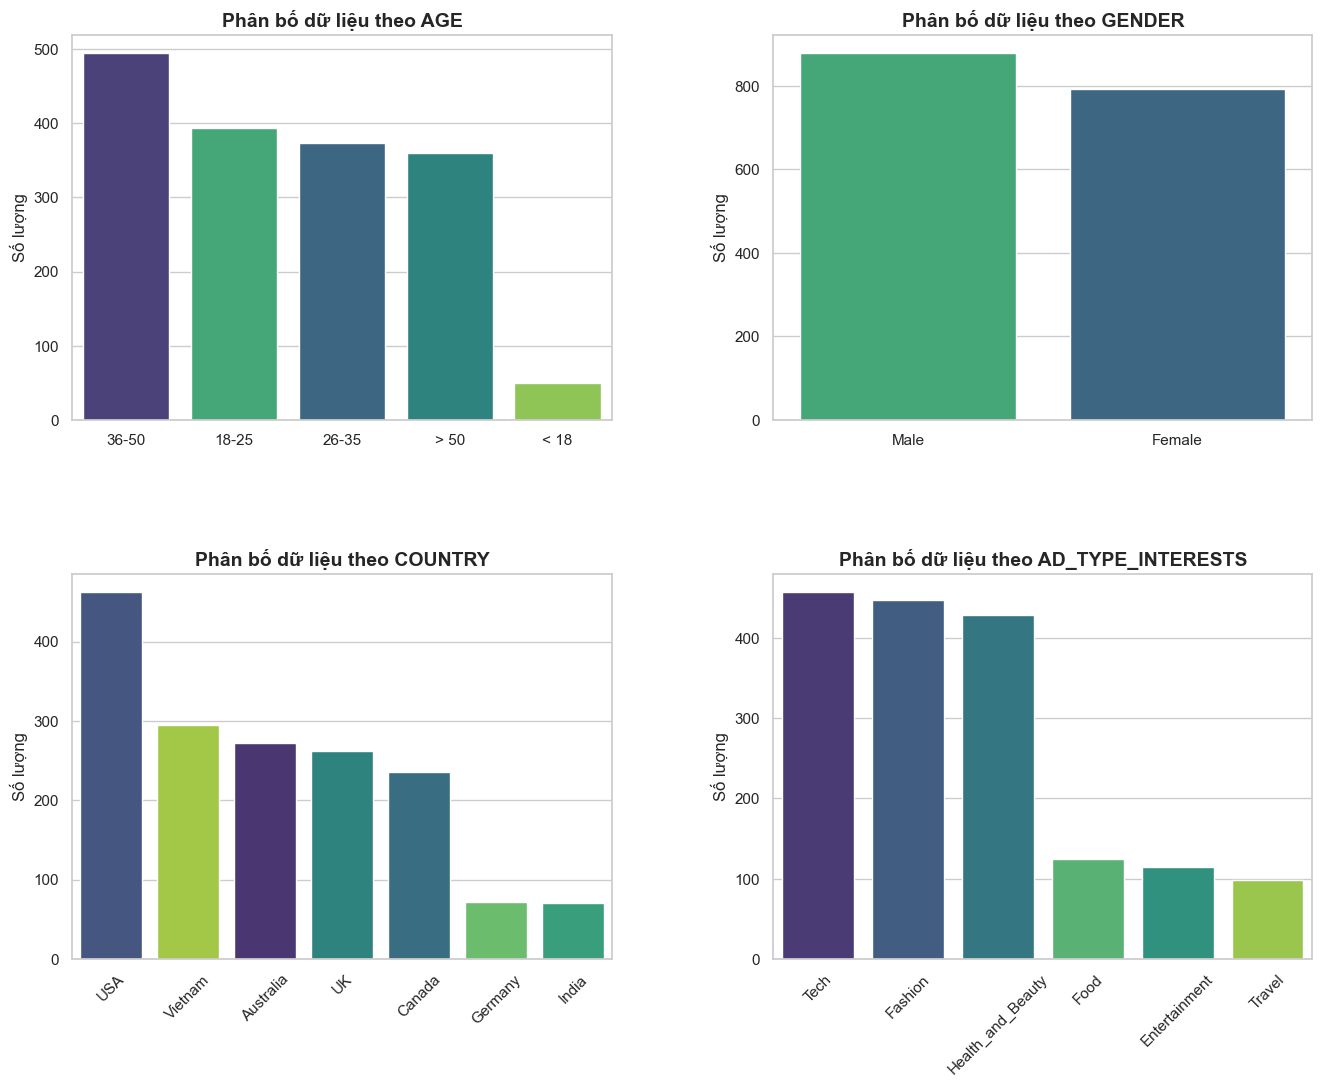

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách cho biểu đồ
sns.set_theme(style="whitegrid")

# Tạo khung hình với 2 hàng và 2 cột
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Danh sách 4 biến cần thống kê
features = ['age', 'gender', 'country', 'ad_type_interests']

for i, col in enumerate(features):
    # Tính toán vị trí hàng và cột trong grid
    ax = axes[i//2, i%2]
    
    # Sắp xếp các cột theo số lượng giảm dần (theo guideline)
    order = df_cleaned[col].value_counts().index
    
    # Vẽ biểu đồ countplot
    sns.countplot(data=df_cleaned, x=col, ax=ax, order=order, palette='viridis', legend=False,hue = col)
    
    # Tinh chỉnh tiêu đề và nhãn
    ax.set_title(f'Phân bố dữ liệu theo {col.upper()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Số lượng')
    
    # Xoay nhãn trục x nếu tên quá dài (đặc biệt là cột country và interests)
    if col in ['country', 'ad_type_interests']:
        ax.tick_params(axis='x', rotation=45)

# Lưu biểu đồ ra file
plt.savefig('distribution_charts.png', bbox_inches='tight')

## 3. Mã hóa dữ liệu

#### Chia 80-20 cho tập Train & Test

In [92]:
from sklearn.model_selection import train_test_split
#Biếc đặc trưng
X = df_cleaned.drop(columns=['ad_type_interests'])
#Biến mục tiêu
y = df_cleaned['ad_type_interests']
#Chia dữ liệu thành tập Train (80%) và tập Test (20%)
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
# Bước 2: Chia tập Train Train_chính_thức (80%) và tập Validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_temp
)

print(f"Tổng mẫu: {len(df_cleaned)}")
print(f"Tập Train: {X_train.shape[0]} mẫu")
print(f"Tập Validation: {X_val.shape[0]} mẫu")
print(f"Tập Test: {X_test.shape[0]} mẫu")

Tổng mẫu: 1670
Tập Train: 1068 mẫu
Tập Validation: 268 mẫu
Tập Test: 334 mẫu


#### Label encoding cho cột Age

In [93]:
age_mapping = {
    '< 18': 0,
    '18-25': 1,
    '26-35': 2,
    '36-50': 3,
    '> 50': 4
}

X_train['age'] = X_train['age'].map(age_mapping)
X_val['age'] = X_val['age'].map(age_mapping)
X_test['age'] = X_test['age'].map(age_mapping)

#### Mã hóa Feature_engine cho Gender & Country

In [96]:
from feature_engine.encoding import OneHotEncoder

ohe_encoder = OneHotEncoder(
    variables=['gender', 'country'],
)

ohe_encoder.fit(X_train)

X_train = ohe_encoder.transform(X_train)
X_val = ohe_encoder.transform(X_val)
X_test = ohe_encoder.transform(X_test)

print("Kích thước tập Train sau mã hóa:", X_train.shape)
print(X_train.head())
print(f"Số lượng cột sau khi encoded: {X_train.shape[1]}")

Kích thước tập Train sau mã hóa: (1068, 10)
     age  gender_Male  gender_Female  country_Canada  country_Australia  \
972    3            1              0               1                  0   
910    1            1              0               0                  1   
754    3            1              0               1                  0   
604    3            0              1               0                  0   
610    3            1              0               0                  1   

     country_USA  country_Vietnam  country_UK  country_Germany  country_India  
972            0                0           0                0              0  
910            0                0           0                0              0  
754            0                0           0                0              0  
604            1                0           0                0              0  
610            0                0           0                0              0  
Số lượng cột sau khi enco

In [97]:
train_set = pd.concat([X_train, y_train], axis=1)
val_set = pd.concat([X_val, y_val], axis=1)
test_set = pd.concat([X_test, y_test], axis=1)

train_set.to_csv('./data/train_data.csv', index=False)
val_set.to_csv('./data/val_data.csv', index=False)
test_set.to_csv('./data/test_data.csv', index=False)

print("Đã lưu thành công 3 tệp dữ liệu sạch!")

Đã lưu thành công 3 tệp dữ liệu sạch!
